# RETINA-ND — Human Retina Cell Atlas (HRCA) cell-type localization

**Purpose:** contextualize the already-frozen top 20 RETINA-ND multimodal candidate genes in normal adult human retinal cell classes.

This notebook **does not rerank candidates**, **does not perform AD/PD differential expression**, and **does not treat cells as independent biological replicates**. It aggregates raw counts at the **donor × major retinal cell-class** level and summarizes expression across donors.

Primary reference: Li et al., *Nature Genetics* (2026), Human Retina Cell Atlas (HRCA), CELLxGENE collection `4c6eaf5c-6d57-4c76-b1e9-60df8c655f1e`.

Expected repository location when committed:

`RETINA_ND_HRCA_celltype_localization.ipynb`

Expected outputs:

- `publication/source_data/hrca_celltype_localization/HRCA_top20_donor_cellclass.csv`
- `publication/source_data/hrca_celltype_localization/HRCA_top20_cellclass_summary.csv`
- `publication/source_data/hrca_celltype_localization/HRCA_top20_provenance.json`
- `publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.png`
- `publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.pdf`


In [4]:
# Colab/runtime setup
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Touf00/retina-ad-pd-glial-convergence.git"
BRANCH = "reproducibility-audit"
REPO_NAME = "retina-ad-pd-glial-convergence"

if "google.colab" in sys.modules:
    root = Path("/content") / REPO_NAME
    if not root.exists():
        subprocess.run(["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, str(root)], check=True)
    os.chdir(root)
else:
    # Run from repository root when using a local/Jupyter environment.
    root = Path.cwd()
    if root.name != REPO_NAME:
        print("WARNING: run this notebook from the repository root or adjust the working directory.")

print("Working directory:", Path.cwd())


Working directory: /content/retina-ad-pd-glial-convergence


In [5]:
# Install only what is needed for the atlas query and plotting.
# In Colab this should remain modest because only 20 genes are queried.
%pip -q install "cellxgene-census>=1.15,<2" anndata pyarrow pandas numpy scipy matplotlib requests


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69

In [6]:
import json
import math
import re
import unicodedata
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import scipy.sparse as sp
import matplotlib.pyplot as plt
import cellxgene_census

# Reproducibility pin. HRCA must be present in this LTS build.
CENSUS_VERSION = "2025-11-08"
HRCA_COLLECTION_ID = "4c6eaf5c-6d57-4c76-b1e9-60df8c655f1e"
HRCA_DATASET_TITLE = "snRNA-seq of human retina - all cells"

TOP20 = [
    "SCAMP5","XYLB","RABEPK","ITGAM","CD38","CTCF","UBTD2","NAPEPLD",
    "GAPDH","STX1B","NDUFB10","NT5C","NPEPL1","BPHL","PURB","OXLD1",
    "PSMC3","LINGO1","SRP14","PTGES2"
]

SOURCE_TOP20 = Path("publication/source_data/pathway_multimodal/final_evidence/RETINA-ND_FIGURE4_TOP20_AUDIT_v1.csv")
OUT_SOURCE = Path("publication/source_data/hrca_celltype_localization")
OUT_FIG = Path("publication/figures/supplementary")
OUT_SOURCE.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

if SOURCE_TOP20.exists():
    frozen = pd.read_csv(SOURCE_TOP20).sort_values("candidate_rank")
    assert frozen["gene_symbol"].tolist()[:20] == TOP20, "Frozen top-20 ranking differs from notebook constant."
    print("Frozen top-20 ranking verified against repository source table.")
else:
    raise FileNotFoundError(SOURCE_TOP20)


Frozen top-20 ranking verified against repository source table.


In [7]:
# Discover the exact HRCA dataset ID from the authoritative CELLxGENE collection.
api = f"https://api.cellxgene.cziscience.com/curation/v1/collections/{HRCA_COLLECTION_ID}"
collection = requests.get(api, timeout=60)
collection.raise_for_status()
collection = collection.json()

matches = [d for d in collection.get("datasets", []) if d.get("title") == HRCA_DATASET_TITLE]
if len(matches) != 1:
    raise RuntimeError(f"Expected exactly one HRCA all-cell snRNA dataset, found {len(matches)}")

ds = matches[0]
DATASET_ID = ds["dataset_id"]
DATASET_VERSION_ID = ds.get("dataset_version_id")
print("HRCA dataset:", HRCA_DATASET_TITLE)
print("dataset_id:", DATASET_ID)
print("dataset_version_id:", DATASET_VERSION_ID)
print("cell_count reported by Discover:", ds.get("cell_count"))


HRCA dataset: snRNA-seq of human retina - all cells
dataset_id: d6505c89-c43d-4c28-8c4f-7351a5fd5528
dataset_version_id: 25f1558d-c1f8-49f8-addc-b778d8cbd4aa
cell_count reported by Discover: 3177310


In [8]:
# Map actual HRCA/CELLxGENE ontology labels to conservative major retinal classes.
# Uncertain labels remain "Other" rather than being forced into a class.

def normalize_label(x):
    x = "" if pd.isna(x) else str(x)
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    return x.lower().strip()


def major_retinal_class(label):
    x = normalize_label(label)

    # Glia
    if "muller" in x or "mueller" in x:
        return "Muller glia"

    if "astrocyte" in x:
        return "Astrocyte"

    if "microgl" in x:
        return "Microglia"

    # Retinal ganglion cells
    if (
        "ganglion cell" in x
        or "midget ganglion" in x
        or "parasol ganglion" in x
    ):
        return "Retinal ganglion cell"

    # Inner retinal neurons
    if "bipolar" in x:
        return "Bipolar cell"

    if "amacrine" in x:
        return "Amacrine cell"

    if "horizontal" in x:
        return "Horizontal cell"

    # Photoreceptors
    if "rod" in x and "bipolar" not in x:
        return "Rod"

    if (
        "cone cell" in x
        or "cone photoreceptor" in x
        or x.startswith("s cone")
        or x.startswith("m cone")
        or x.startswith("l cone")
    ):
        return "Cone"

    # RPE
    if "retinal pigment epithelial" in x or "pigment epithelial" in x:
        return "RPE"

    # Vascular
    if "endothelial" in x:
        return "Endothelial"

    if "pericyte" in x or "mural" in x:
        return "Pericyte/mural"

    # Other immune
    if (
        "macrophage" in x
        or "monocyte" in x
        or "lymphocyte" in x
        or "t cell" in x
        or "b cell" in x
    ):
        return "Other immune"

    return "Other"


DISPLAY_ORDER = [
    "Muller glia",
    "Astrocyte",
    "Microglia",
    "Retinal ganglion cell",
    "Bipolar cell",
    "Amacrine cell",
    "Horizontal cell",
    "Rod",
    "Cone",
    "RPE",
    "Endothelial",
    "Pericyte/mural",
    "Other immune",
]

In [9]:
# Open the pinned Census release and verify the HRCA dataset is actually present.
with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
    info = census["census_info"]["summary"].read().concat().to_pandas()
    info_dict = dict(zip(info["label"], info["value"]))
    build_date = info_dict.get("census_build_date")

    ds_table = census["census_info"]["datasets"].read(
        value_filter=f"dataset_id == '{DATASET_ID}'"
    ).concat().to_pandas()

    if ds_table.empty:
        raise RuntimeError(
            f"HRCA dataset {DATASET_ID} is not present in Census {CENSUS_VERSION}. "
            "Use a newer *pinned* Census build, not an unrecorded rolling query."
        )

    print("Census build date:", build_date)
    print(ds_table[["dataset_id","dataset_title","dataset_version_id","dataset_total_cell_count"]])


Census build date: 2025-11-08
                             dataset_id  \
0  d6505c89-c43d-4c28-8c4f-7351a5fd5528   

                           dataset_title  \
0  snRNA-seq of human retina - all cells   

                     dataset_version_id  dataset_total_cell_count  
0  b4b58102-d03b-47b9-93b1-ed419b042de7                   3177310  


In [10]:
# Retrieve HRCA metadata first.
# Primary analysis is restricted to adult (>=18 y), normal/reference human retina.

OBS_COLS = [
    "donor_id",
    "cell_type",
    "development_stage",
    "disease",
    "tissue",
    "raw_sum",
    "is_primary_data",
]

with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
    obs = cellxgene_census.get_obs(
        census,
        "Homo sapiens",
        value_filter=f"dataset_id == '{DATASET_ID}' and is_primary_data == True",
        column_names=OBS_COLS,
    )

print("All primary observations:", f"{len(obs):,}")
print("All donors:", obs["donor_id"].nunique())

# Confirm disease status
print("\nDisease labels:")
print(obs["disease"].value_counts(dropna=False).head(20))

# HRCA dataset is expected to be normal/reference.
normal_mask = obs["disease"].astype(str).str.lower().eq("normal")
print("\nNormal cells:", f"{normal_mask.sum():,}")

obs = obs.loc[normal_mask].copy()


# -----------------------
# Adult restriction
# -----------------------

def extract_numeric_age(stage):
    s = str(stage).lower()

    # Explicit 90+ category
    if "90 year-old and over" in s:
        return 90.0

    # Standard CELLxGENE labels such as "69-year-old stage"
    m = re.search(r"(\d+)\s*-\s*year-old", s)
    if m:
        return float(m.group(1))

    # Broader adult ontology labels
    if "adult" in s:
        return 18.0

    return np.nan


obs["numeric_age"] = obs["development_stage"].map(extract_numeric_age)

# Keep explicitly adult age/stage.
adult_mask = obs["numeric_age"].ge(18)

print("\nCells excluded because age/stage is <18 or not explicitly adult:",
      f"{(~adult_mask).sum():,}")

obs = obs.loc[adult_mask].copy()

eligible_donors = sorted(
    obs["donor_id"].dropna().astype(str).unique()
)

print("Adult primary observations:", f"{len(obs):,}")
print("Adult donors:", len(eligible_donors))


# -----------------------
# Cell-class harmonization
# -----------------------

obs["major_class"] = obs["cell_type"].map(major_retinal_class)

coverage = 1 - (obs["major_class"] == "Other").mean()

print(f"\nMajor-class mapping coverage: {coverage:.2%}")

mapping_audit = (
    obs.groupby(["cell_type", "major_class"], observed=True)
       .size()
       .reset_index(name="n_cells")
       .sort_values("n_cells", ascending=False)
)

display(mapping_audit.head(100))


# Show anything still unmapped
unmapped = mapping_audit.loc[
    mapping_audit["major_class"] == "Other"
].copy()

print("\nLargest remaining unmapped labels:")
display(unmapped.head(30))


if coverage < 0.90:
    raise RuntimeError(
        "Major-class mapping still covers <90% of adult HRCA cells. "
        "Do not proceed until remaining ontology labels are reviewed."
    )

All primary observations: 2,907,910
All donors: 100

Disease labels:
disease
normal                                                           2907910
kidney benign neoplasm                                                 0
kidney oncocytoma                                                      0
leukoencephalopathy, diffuse hereditary, with spheroids 1              0
listeriosis                                                            0
liver cancer                                                           0
localized scleroderma                                                  0
long COVID-19                                                          0
luminal A breast carcinoma                                             0
luminal B breast carcinoma                                             0
lung adenocarcinoma                                                    0
lung cancer                                                            0
lung large cell carcinoma                      

,cell_type,major_class,n_cells
28,retinal rod cell,Rod,909275
0,GABAergic amacrine cell,Amacrine cell,309333
3,Mueller cell,Muller glia,193241
4,OFF midget ganglion cell,Retinal ganglion cell,191072
7,ON midget ganglion cell,Retinal ganglion cell,145739
19,flat midget bipolar cell,Bipolar cell,125476
21,glycinergic amacrine cell,Amacrine cell,110408
25,retinal cone cell,Cone,103339
22,invaginating midget bipolar cell,Bipolar cell,88991
29,rod bipolar cell,Bipolar cell,84896



Largest remaining unmapped labels:


,cell_type,major_class,n_cells
6,OFFx cell,Other,14684


In [ ]:
# PILOT ONLY: query 2 small adult donors × frozen top-20 genes.
# Do not process all 89 donors yet.

# Choose two relatively small donors among confidently mapped adult cells.
pilot_donors = (
    obs.loc[obs["major_class"] != "Other"]
       .groupby("donor_id", observed=True)
       .size()
       .sort_values()
       .head(2)
       .index.astype(str)
       .tolist()
)

print("Pilot donors:", pilot_donors)

def quote_values(vals):
    return "[" + ", ".join(repr(str(v)) for v in vals) + "]"

donor_filter = quote_values(pilot_donors)
gene_filter = "[" + ", ".join(repr(g) for g in TOP20) + "]"

obs_filter = (
    f"dataset_id == '{DATASET_ID}' "
    f"and is_primary_data == True "
    f"and donor_id in {donor_filter}"
)

var_filter = f"feature_name in {gene_filter}"

with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
    pilot = cellxgene_census.get_anndata(
        census=census,
        organism="Homo sapiens",
        X_name="raw",
        obs_value_filter=obs_filter,
        var_value_filter=var_filter,
        obs_column_names=[
            "donor_id",
            "cell_type",
            "development_stage",
            "disease",
            "tissue",
            "raw_sum",
        ],
        var_column_names=[
            "feature_id",
            "feature_name",
        ],
    )

print("\nPilot matrix shape:", pilot.shape)
print("Cells retrieved:", f"{pilot.n_obs:,}")
print("Features retrieved:", pilot.n_vars)

print("\nGenes retrieved:")
print(pilot.var["feature_name"].value_counts())

pilot.obs["major_class"] = pilot.obs["cell_type"].map(major_retinal_class)

print("\nMajor retinal classes in pilot:")
print(
    pilot.obs["major_class"]
         .value_counts()
         .to_string()
)

print("\nSparse matrix:", sp.issparse(pilot.X))

if sp.issparse(pilot.X):
    print("Nonzero expression entries:", f"{pilot.X.nnz:,}")

missing = sorted(set(TOP20) - set(pilot.var["feature_name"].astype(str)))
print("\nMissing top-20 genes:", missing)

assert pilot.n_obs > 0
assert pilot.n_vars > 0

Pilot donors: ['BCM_24_0080', 'sanes2022_Hu082219']


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)



Pilot matrix shape: (8018, 20)
Cells retrieved: 8,018
Features retrieved: 20

Genes retrieved:
feature_name
XYLB       1
UBTD2      1
BPHL       1
PURB       1
NAPEPLD    1
RABEPK     1
PTGES2     1
PSMC3      1
GAPDH      1
SRP14      1
LINGO1     1
NDUFB10    1
ITGAM      1
CTCF       1
NT5C       1
OXLD1      1
NPEPL1     1
CD38       1
STX1B      1
SCAMP5     1
Name: count, dtype: int64

Major retinal classes in pilot:
major_class
Rod                      2660
Bipolar cell             2055
Muller glia               948
Amacrine cell             874
Retinal ganglion cell     508
Horizontal cell           418
Cone                      317
Astrocyte                 126
RPE                        98
Other                      14

Sparse matrix: True
Nonzero expression entries: 28,577

Missing top-20 genes: []


In [11]:
# Donor-aware aggregation.
# We query only the 20 frozen genes, in donor batches, and use cell-level raw_sum to compute
# true donor × major-class pseudobulk CPM denominators without downloading the whole transcriptome.

def quote_values(vals):
    return "[" + ", ".join(repr(str(v)) for v in vals) + "]"

BATCH_SIZE = 8
donor_records = []

for start in range(0, len(eligible_donors), BATCH_SIZE):
    donor_batch = eligible_donors[start:start+BATCH_SIZE]
    donor_filter = quote_values(donor_batch)
    gene_filter = "[" + ", ".join(repr(g) for g in TOP20) + "]"

    obs_filter = (
        f"dataset_id == '{DATASET_ID}' and is_primary_data == True "
        f"and donor_id in {donor_filter}"
    )
    var_filter = f"feature_name in {gene_filter}"

    with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
        adata = cellxgene_census.get_anndata(
            census=census,
            organism="Homo sapiens",
            X_name="raw",
            obs_value_filter=obs_filter,
            var_value_filter=var_filter,
            obs_column_names=["donor_id","cell_type","development_stage","disease","tissue","raw_sum"],
            var_column_names=["feature_id","feature_name"],
        )

    if adata.n_obs == 0:
        continue

    aobs = adata.obs.copy()
    aobs["major_class"] = aobs["cell_type"].map(major_retinal_class)
    aobs = aobs[aobs["major_class"] != "Other"].copy()

    X = adata.X.tocsr() if sp.issparse(adata.X) else sp.csr_matrix(adata.X)
    feature_names = adata.var["feature_name"].astype(str).to_numpy()

    # Combine duplicate feature_name entries, if present, by summing their raw counts.
    counts_by_gene = {}
    for gene in TOP20:
        cols = np.flatnonzero(feature_names == gene)
        if len(cols) == 0:
            counts_by_gene[gene] = np.zeros(adata.n_obs, dtype=np.float32)
        else:
            counts_by_gene[gene] = np.asarray(X[:, cols].sum(axis=1)).ravel()

    count_df = pd.DataFrame(counts_by_gene, index=adata.obs_names)
    count_df = count_df.loc[aobs.index]
    work = aobs[["donor_id","major_class","raw_sum"]].join(count_df)

    group_cols = ["donor_id","major_class"]
    denom = work.groupby(group_cols, observed=True).agg(
        n_cells=("raw_sum","size"),
        library_counts=("raw_sum","sum")
    ).reset_index()

    sums = work.groupby(group_cols, observed=True)[TOP20].sum().reset_index()
    det = work.assign(**{g: (work[g] > 0).astype(np.int32) for g in TOP20})
    det = det.groupby(group_cols, observed=True)[TOP20].sum().reset_index()

    for _, row in denom.iterrows():
        donor = str(row["donor_id"])
        cls = row["major_class"]
        n_cells = int(row["n_cells"])
        lib = float(row["library_counts"])

        srow = sums[(sums["donor_id"] == row["donor_id"]) & (sums["major_class"] == cls)].iloc[0]
        drow = det[(det["donor_id"] == row["donor_id"]) & (det["major_class"] == cls)].iloc[0]

        for rank, gene in enumerate(TOP20, start=1):
            gene_counts = float(srow[gene])
            detected_cells = int(drow[gene])
            donor_records.append({
                "gene": gene,
                "original_rank": rank,
                "donor_id": donor,
                "retinal_cell_class": cls,
                "n_cells": n_cells,
                "library_counts": lib,
                "gene_counts": gene_counts,
                "pseudobulk_CPM": (gene_counts / lib * 1e6) if lib > 0 else np.nan,
                "detected_cells": detected_cells,
                "cell_detection_fraction": detected_cells / n_cells if n_cells else np.nan,
                "donor_detected": int(gene_counts > 0),
            })

    print(f"Processed donors {start+1}-{min(start+BATCH_SIZE, len(eligible_donors))} / {len(eligible_donors)}")

donor_df = pd.DataFrame(donor_records)
donor_df.to_csv(OUT_SOURCE / "HRCA_top20_donor_cellclass.csv", index=False)
print("Donor-level rows:", f"{len(donor_df):,}")


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Processed donors 1-8 / 89


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Processed donors 9-16 / 89


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


...

Processed donors 73-80 / 89


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Processed donors 81-88 / 89


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Processed donors 89-89 / 89
Donor-level rows: 15,240


In [12]:
# Summarize across donors. Donors, not cells, are the unit of replication/contextualization.
summary = (
    donor_df.groupby(["gene","original_rank","retinal_cell_class"], observed=True)
    .agg(
        n_donors=("donor_id","nunique"),
        median_CPM=("pseudobulk_CPM","median"),
        q25_CPM=("pseudobulk_CPM", lambda x: x.quantile(0.25)),
        q75_CPM=("pseudobulk_CPM", lambda x: x.quantile(0.75)),
        donor_detection_fraction=("donor_detected","mean"),
        median_cell_detection_fraction=("cell_detection_fraction","median"),
        total_cells=("n_cells","sum"),
    )
    .reset_index()
)

# Keep all expected classes explicit, even when absent.
grid = pd.MultiIndex.from_product(
    [TOP20, DISPLAY_ORDER],
    names=["gene","retinal_cell_class"]
).to_frame(index=False)
rank_map = {g:i+1 for i,g in enumerate(TOP20)}
grid["original_rank"] = grid["gene"].map(rank_map)

summary = grid.merge(
    summary,
    on=["gene","original_rank","retinal_cell_class"],
    how="left"
).sort_values(["original_rank","retinal_cell_class"])

summary.to_csv(OUT_SOURCE / "HRCA_top20_cellclass_summary.csv", index=False)
display(summary.head(30))


,gene,retinal_cell_class,original_rank,n_donors,median_CPM,q25_CPM,q75_CPM,donor_detection_fraction,median_cell_detection_fraction,total_cells
5,SCAMP5,Amacrine cell,1,89.0,129.080564,115.692764,139.026498,1.000000,0.520900,485681.0
1,SCAMP5,Astrocyte,1,68.0,32.189813,22.479871,41.666403,0.955882,0.137067,10789.0
4,SCAMP5,Bipolar cell,1,89.0,116.812289,102.522675,132.487050,1.000000,0.383812,583095.0
8,SCAMP5,Cone,1,83.0,202.303525,166.561309,229.480280,1.000000,0.720497,110829.0
10,SCAMP5,Endothelial,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SCAMP5,Horizontal cell,1,82.0,80.235865,70.992442,91.078074,1.000000,0.409552,64116.0
2,SCAMP5,Microglia,1,68.0,26.082904,13.034577,38.039759,0.838235,0.064516,4275.0
0,SCAMP5,Muller glia,1,86.0,22.833224,18.155478,27.958506,0.988372,0.089177,193241.0
12,SCAMP5,Other immune,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,SCAMP5,Pericyte/mural,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Diagnostic summary before Figure S8.
# Shows, for every frozen candidate, the retinal class with the highest
# donor-median pseudobulk CPM and the strongest donor detection.

diagnostic = (
    summary.dropna(subset=["median_CPM"])
           .copy()
)

# Exclude classes absent from HRCA and do not use "Other"
diagnostic = diagnostic[
    ~diagnostic["retinal_cell_class"].isin(
        ["Endothelial", "Pericyte/mural", "Other immune"]
    )
].copy()

top_expression = (
    diagnostic.sort_values(
        ["original_rank", "median_CPM"],
        ascending=[True, False]
    )
    .groupby(["gene", "original_rank"], as_index=False)
    .first()[
        [
            "original_rank",
            "gene",
            "retinal_cell_class",
            "median_CPM",
            "n_donors",
            "donor_detection_fraction",
            "median_cell_detection_fraction",
        ]
    ]
    .rename(
        columns={
            "retinal_cell_class": "highest_expression_class",
            "median_CPM": "highest_median_CPM",
            "n_donors": "n_donors_in_top_class",
            "donor_detection_fraction": "donor_detection_in_top_class",
            "median_cell_detection_fraction": "cell_detection_in_top_class",
        }
    )
)

# Also identify where each gene is most broadly detected across donors.
top_detection = (
    diagnostic.sort_values(
        ["original_rank", "donor_detection_fraction", "median_CPM"],
        ascending=[True, False, False]
    )
    .groupby(["gene", "original_rank"], as_index=False)
    .first()[
        [
            "original_rank",
            "gene",
            "retinal_cell_class",
            "donor_detection_fraction",
        ]
    ]
    .rename(
        columns={
            "retinal_cell_class": "highest_donor_detection_class",
            "donor_detection_fraction": "max_donor_detection_fraction",
        }
    )
)

candidate_context = (
    top_expression.merge(
        top_detection,
        on=["original_rank", "gene"],
        how="left"
    )
    .sort_values("original_rank")
)

display(candidate_context)

# Save for manuscript interpretation/provenance.
candidate_context.to_csv(
    OUT_SOURCE / "HRCA_top20_candidate_context_summary.csv",
    index=False
)

print("\nCandidates:", len(candidate_context))
print("\nHighest-expression retinal classes:")
print(candidate_context["highest_expression_class"].value_counts())

,original_rank,gene,highest_expression_class,highest_median_CPM,n_donors_in_top_class,donor_detection_in_top_class,cell_detection_in_top_class,highest_donor_detection_class,max_donor_detection_fraction
15,1,SCAMP5,Rod,400.472592,88.0,1.000000,0.705597,Rod,1.000000
19,2,XYLB,Amacrine cell,64.653820,89.0,1.000000,0.313259,Amacrine cell,1.000000
14,3,RABEPK,Retinal ganglion cell,39.867726,89.0,1.000000,0.356599,Retinal ganglion cell,1.000000
4,4,ITGAM,Microglia,137.736586,68.0,0.985294,0.296667,Microglia,0.985294
1,5,CD38,Cone,99.557292,83.0,1.000000,0.456710,Cone,1.000000
2,6,CTCF,Microglia,62.145944,68.0,0.897059,0.130791,Horizontal cell,1.000000
18,7,UBTD2,Horizontal cell,52.362938,82.0,0.987805,0.247311,Retinal ganglion cell,1.000000
6,8,NAPEPLD,Bipolar cell,141.613481,89.0,1.000000,0.435761,Bipolar cell,1.000000
3,9,GAPDH,Horizontal cell,948.561722,82.0,1.000000,0.960163,Horizontal cell,1.000000
17,10,STX1B,Amacrine cell,57.772792,89.0,1.000000,0.299183,Amacrine cell,1.000000



Candidates: 20

Highest-expression retinal classes:
highest_expression_class
Horizontal cell          6
Microglia                4
Amacrine cell            4
Rod                      3
Retinal ganglion cell    1
Cone                     1
Bipolar cell             1
Name: count, dtype: int64


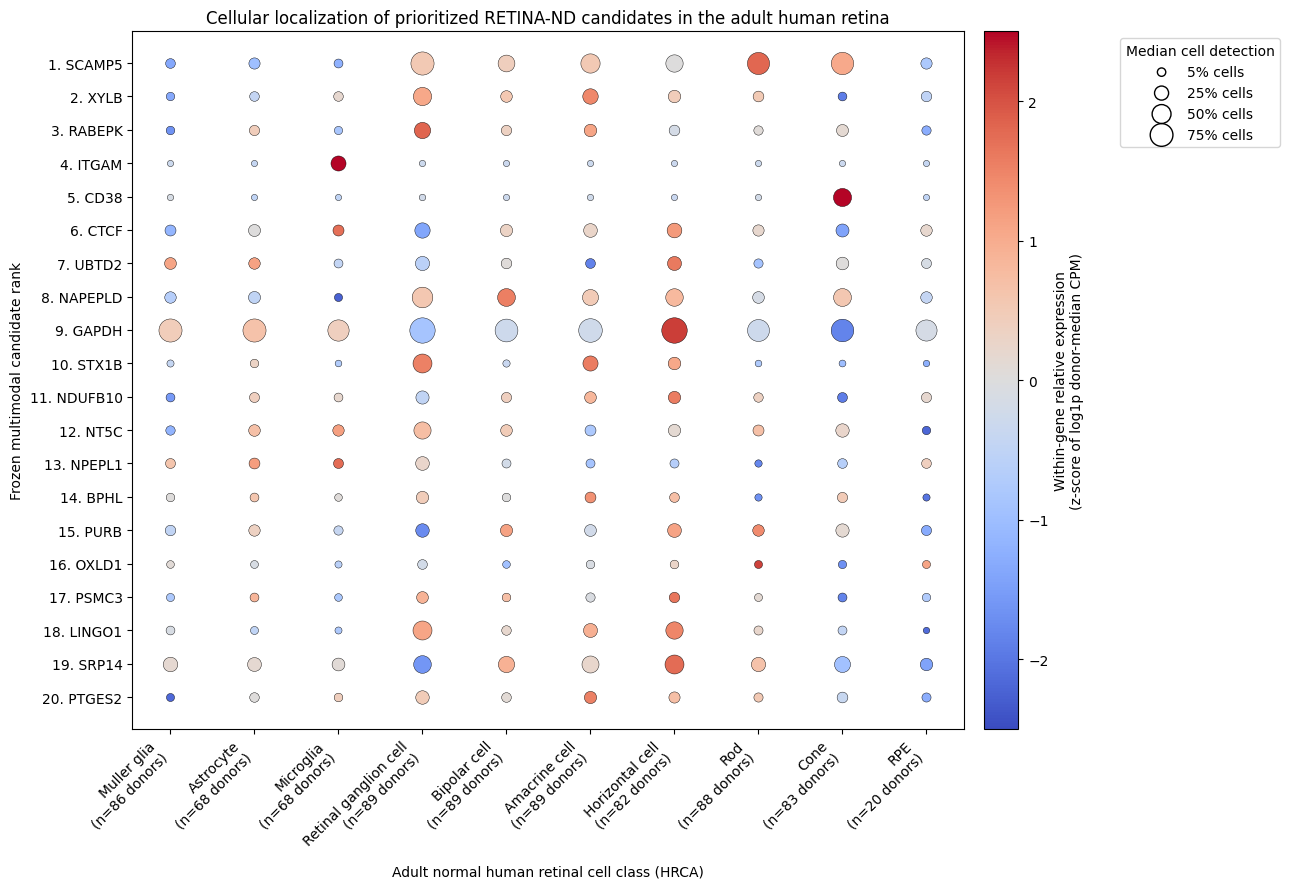

Saved:
publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.png
publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.pdf


In [14]:
# Final Figure S8
# Color = within-gene relative expression across retinal cell classes
# Dot size = median fraction of cells expressing the gene
# Candidate order remains the frozen RETINA-ND rank.

PLOT_CLASSES = [
    "Muller glia",
    "Astrocyte",
    "Microglia",
    "Retinal ganglion cell",
    "Bipolar cell",
    "Amacrine cell",
    "Horizontal cell",
    "Rod",
    "Cone",
    "RPE",
]

plot_df = summary[
    summary["retinal_cell_class"].isin(PLOT_CLASSES)
].copy()

# log-transform donor-median CPM before within-gene standardization
plot_df["log1p_median_CPM"] = np.log1p(
    plot_df["median_CPM"].fillna(0)
)

def within_gene_z(x):
    sd = x.std(ddof=0)

    if (not np.isfinite(sd)) or sd == 0:
        return pd.Series(
            np.zeros(len(x)),
            index=x.index
        )

    return (x - x.mean()) / sd

plot_df["relative_expression_z"] = (
    plot_df.groupby("gene", sort=False)["log1p_median_CPM"]
           .transform(within_gene_z)
)

# Maximum available donor coverage for each retinal class.
class_n = (
    plot_df.groupby("retinal_cell_class")["n_donors"]
           .max()
           .reindex(PLOT_CLASSES)
)

xlabels = [
    f"{cell_class}\n(n={int(class_n[cell_class])} donors)"
    if pd.notna(class_n[cell_class])
    else cell_class
    for cell_class in PLOT_CLASSES
]

x_map = {c: i for i, c in enumerate(PLOT_CLASSES)}
y_map = {g: i for i, g in enumerate(TOP20)}

fig, ax = plt.subplots(figsize=(13, 9))

for _, r in plot_df.iterrows():

    x = x_map[r["retinal_cell_class"]]
    y = y_map[r["gene"]]

    # Cell-level prevalence is descriptive only;
    # donors remain the biological aggregation unit.
    detection = (
        0.0
        if pd.isna(r["median_cell_detection_fraction"])
        else float(r["median_cell_detection_fraction"])
    )

    # Keep low-expression populations visible while retaining dynamic range.
    size = 20 + 330 * detection

    value = (
        0.0
        if pd.isna(r["relative_expression_z"])
        else float(r["relative_expression_z"])
    )

    ax.scatter(
        x,
        y,
        s=size,
        c=[value],
        cmap="coolwarm",
        vmin=-2.5,
        vmax=2.5,
        edgecolors="black",
        linewidths=0.3,
    )

ax.set_xticks(range(len(PLOT_CLASSES)))
ax.set_xticklabels(
    xlabels,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(TOP20)))
ax.set_yticklabels(
    [f"{i+1}. {gene}" for i, gene in enumerate(TOP20)]
)

ax.invert_yaxis()

ax.set_xlabel(
    "Adult normal human retinal cell class (HRCA)"
)

ax.set_ylabel(
    "Frozen multimodal candidate rank"
)

ax.set_title(
    "Cellular localization of prioritized RETINA-ND candidates "
    "in the adult human retina"
)

# Color scale
sm = plt.cm.ScalarMappable(
    cmap="coolwarm",
    norm=plt.Normalize(-2.5, 2.5)
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Within-gene relative expression\n"
    "(z-score of log1p donor-median CPM)"
)

# Dot-size legend
handles = []
labels = []

for p in [0.05, 0.25, 0.50, 0.75]:

    handles.append(
        ax.scatter(
            [],
            [],
            s=20 + 330*p,
            facecolors="none",
            edgecolors="black"
        )
    )

    labels.append(
        f"{int(p*100)}% cells"
    )

ax.legend(
    handles,
    labels,
    title="Median cell detection",
    bbox_to_anchor=(1.18, 1),
    loc="upper left"
)

fig.tight_layout()

png = (
    OUT_FIG /
    "Figure_S8_HRCA_top20_celltype_localization.png"
)

pdf = (
    OUT_FIG /
    "Figure_S8_HRCA_top20_celltype_localization.pdf"
)

fig.savefig(
    png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    pdf,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(png)
print(pdf)

In [17]:
# Freeze provenance and perform basic QA.
figure_source = summary.copy()
figure_source.to_csv(OUT_SOURCE / "Figure_S8_HRCA_top20_source_data.csv", index=False)

provenance = {
    "analysis": "RETINA-ND HRCA top-20 retinal cell-type localization",
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "repository_branch": BRANCH,
    "candidate_source": str(SOURCE_TOP20),
    "candidate_order": TOP20,
    "hrca_collection_id": HRCA_COLLECTION_ID,
    "hrca_dataset_title": HRCA_DATASET_TITLE,
    "hrca_dataset_id": DATASET_ID,
    "hrca_dataset_version_id_live_collection": DATASET_VERSION_ID,
"hrca_dataset_version_id_pinned_census": str(ds_table.iloc[0]["dataset_version_id"]),
    "census_version_requested": CENSUS_VERSION,
    "census_build_date": build_date,
    "n_eligible_donors": len(eligible_donors),
    "unit_of_summary": "donor x major retinal cell class",
    "expression_metric": "pseudobulk CPM from raw gene counts / summed per-cell raw_sum",
    "detection_metric": "fraction of donors with gene_counts > 0; cell detection reported descriptively",
    "candidate_reranking": False,
    "disease_inference": False,
    "notes": [
        "Normal adult/reference retinal contextualization only.",
        "Cells are not treated as independent biological replicates.",
        "Unmapped cell labels are retained as Other during mapping QA and excluded from the primary figure.",
    ],
}
with open(OUT_SOURCE / "HRCA_top20_provenance.json", "w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2)

assert set(summary["gene"]) == set(TOP20)
assert summary["original_rank"].min() == 1 and summary["original_rank"].max() == 20
assert donor_df["pseudobulk_CPM"].dropna().ge(0).all()
assert donor_df["cell_detection_fraction"].dropna().between(0,1).all()
assert summary["donor_detection_fraction"].dropna().between(0,1).all()

print("QA passed.")
print("Outputs:")
for p in sorted(OUT_SOURCE.glob("HRCA*")):
    print(" -", p)
print(" -", OUT_SOURCE / "Figure_S8_HRCA_top20_source_data.csv")
print(" -", OUT_FIG / "Figure_S8_HRCA_top20_celltype_localization.png")
print(" -", OUT_FIG / "Figure_S8_HRCA_top20_celltype_localization.pdf")


QA passed.
Outputs:
 - publication/source_data/hrca_celltype_localization/HRCA_top20_candidate_context_summary.csv
 - publication/source_data/hrca_celltype_localization/HRCA_top20_cellclass_summary.csv
 - publication/source_data/hrca_celltype_localization/HRCA_top20_donor_cellclass.csv
 - publication/source_data/hrca_celltype_localization/HRCA_top20_provenance.json
 - publication/source_data/hrca_celltype_localization/Figure_S8_HRCA_top20_source_data.csv
 - publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.png
 - publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.pdf


In [18]:
from pathlib import Path
import zipfile
from google.colab import files

root = Path.cwd()

wanted = [
    root / "publication/source_data/hrca_celltype_localization/HRCA_top20_candidate_context_summary.csv",
    root / "publication/source_data/hrca_celltype_localization/HRCA_top20_cellclass_summary.csv",
    root / "publication/source_data/hrca_celltype_localization/HRCA_top20_donor_cellclass.csv",
    root / "publication/source_data/hrca_celltype_localization/HRCA_top20_provenance.json",
    root / "publication/source_data/hrca_celltype_localization/Figure_S8_HRCA_top20_source_data.csv",
    root / "publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.png",
    root / "publication/figures/supplementary/Figure_S8_HRCA_top20_celltype_localization.pdf",
]

missing = [p for p in wanted if not p.exists()]

if missing:
    print("MISSING:")
    for p in missing:
        print(p)
    raise RuntimeError("Some final HRCA files are missing. Do not close Colab.")
else:
    print("All 7 final HRCA files found.")

zip_path = Path("/content/RETINA_ND_HRCA_FINAL_OUTPUTS.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in wanted:
        z.write(p, arcname=p.name)
        print("ADDED:", p.name)

print("\nCreated:", zip_path)

files.download(str(zip_path))

All 7 final HRCA files found.
ADDED: HRCA_top20_candidate_context_summary.csv
ADDED: HRCA_top20_cellclass_summary.csv
ADDED: HRCA_top20_donor_cellclass.csv
ADDED: HRCA_top20_provenance.json
ADDED: Figure_S8_HRCA_top20_source_data.csv
ADDED: Figure_S8_HRCA_top20_celltype_localization.png
ADDED: Figure_S8_HRCA_top20_celltype_localization.pdf

Created: /content/RETINA_ND_HRCA_FINAL_OUTPUTS.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
names = [
    "donor_df",
    "summary",
    "candidate_context",
    "provenance",
    "plot_df",
]

for name in names:
    print(name, "->", "FOUND IN MEMORY" if name in globals() else "MISSING")

donor_df -> MISSING
summary -> MISSING
candidate_context -> MISSING
provenance -> MISSING
plot_df -> MISSING


In [2]:
from pathlib import Path
import zipfile
from google.colab import files

print("Current working directory:", Path.cwd())

wanted = [
    "HRCA_top20_candidate_context_summary.csv",
    "HRCA_top20_cellclass_summary.csv",
    "HRCA_top20_donor_cellclass.csv",
    "HRCA_top20_provenance.json",
    "Figure_S8_HRCA_top20_source_data.csv",
    "Figure_S8_HRCA_top20_celltype_localization.png",
    "Figure_S8_HRCA_top20_celltype_localization.pdf",
]

found = {}

# Search from the directory where the notebook actually ran.
for name in wanted:
    matches = list(Path.cwd().rglob(name))

    # If not found there, search /content as backup.
    if not matches and Path.cwd() != Path("/content"):
        matches = list(Path("/content").rglob(name))

    if matches:
        found[name] = matches[0]
        print("FOUND:", name)
        print("      ", matches[0])
    else:
        print("MISSING:", name)

print("\nFound", len(found), "of", len(wanted), "files.")

if len(found) == 0:
    raise RuntimeError(
        "No HRCA output files were found. Send me the printed working directory."
    )

zip_path = Path("/content/RETINA_ND_HRCA_FINAL_OUTPUTS.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for name, path in found.items():
        z.write(path, arcname=name)

print("\nCreated:", zip_path)
files.download(str(zip_path))

Current working directory: /content
MISSING: HRCA_top20_candidate_context_summary.csv
MISSING: HRCA_top20_cellclass_summary.csv
MISSING: HRCA_top20_donor_cellclass.csv
MISSING: HRCA_top20_provenance.json
MISSING: Figure_S8_HRCA_top20_source_data.csv
MISSING: Figure_S8_HRCA_top20_celltype_localization.png
MISSING: Figure_S8_HRCA_top20_celltype_localization.pdf

Found 0 of 7 files.


RuntimeError: No HRCA output files were found. Send me the printed working directory.